In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

df = pd.read_csv('/Users/aadesh/finance-analyzer/data/raw/Transaction.csv')

print("Shape of Dataset:")
print(df.shape)

print('\nColumn Names:')
print(df.columns.tolist())

print("\nfirst 5 rows:")
df.head()

Shape of Dataset:
(6362620, 11)

Column Names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

first 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [8]:
print('Data types and non-null Counts:')
print(df.info())

print("\nmissing values per column:")
print(df.isnull().sum())

print("\nbasic statistics:")
df.describe()

Data types and non-null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB
None

missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

basic statistics:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [9]:
print("Fraud Distribution")
print(df['isFraud'].value_counts())

print("\nfraud percentage:")
print(df['isFraud'].value_counts(normalize=True) * 100)

print("\ntransaction types:")
print(df['type'].value_counts())

print("\nfraud by transaction type:")
print(df.groupby('type')['isFraud'].sum())

Fraud Distribution
isFraud
0    6354407
1       8213
Name: count, dtype: int64

fraud percentage:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

transaction types:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

fraud by transaction type:
type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64


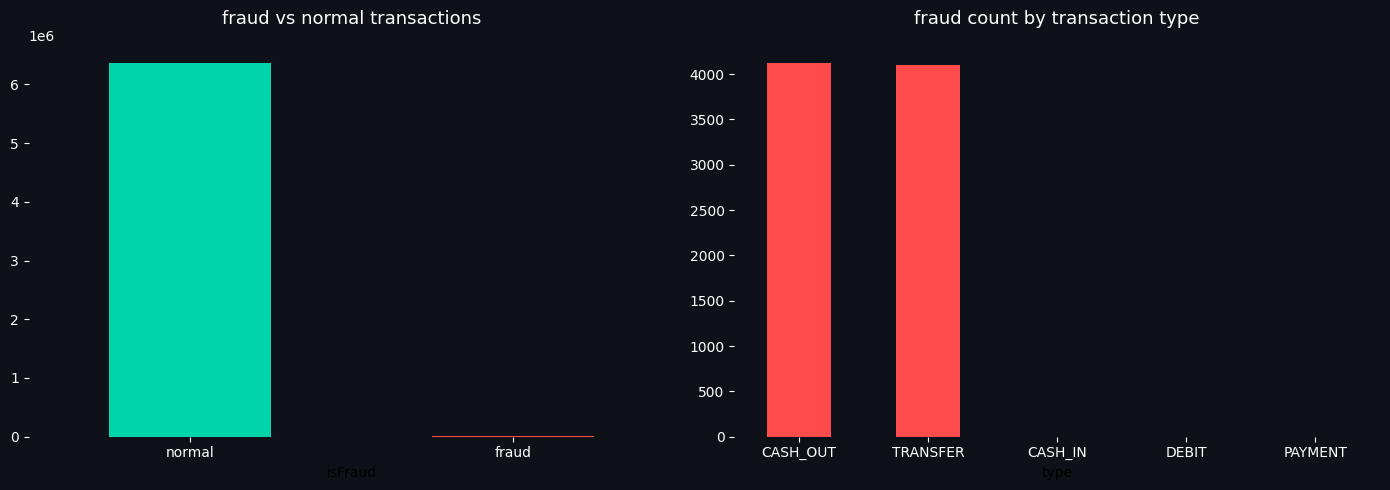

chart saved to reports folder!


In [10]:
# ============================================
# Visualize fraud distribution
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0e1117')

# plot 1 — fraud vs normal
axes[0].set_facecolor('#0e1117')
colors = ['#00d4aa', '#ff4b4b']
df['isFraud'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=colors,
    edgecolor='none',
    width=0.5
)
axes[0].set_title('fraud vs normal transactions',
                   color='white', pad=15, fontsize=13)
axes[0].set_xticklabels(['normal', 'fraud'],
                          rotation=0, color='white')
axes[0].tick_params(colors='white')
axes[0].spines[['top','right','left','bottom']].set_visible(False)
axes[0].set_facecolor('#0e1117')
for spine in axes[0].spines.values():
    spine.set_visible(False)

# plot 2 — fraud by transaction type
axes[1].set_facecolor('#0e1117')
fraud_by_type = df.groupby('type')['isFraud'].sum().sort_values(ascending=False)
fraud_by_type.plot(
    kind='bar',
    ax=axes[1],
    color='#ff4b4b',
    edgecolor='none',
    width=0.5
)
axes[1].set_title('fraud count by transaction type',
                   color='white', pad=15, fontsize=13)
axes[1].tick_params(colors='white', rotation=0)
axes[1].spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/fraud_distribution.png',
            dpi=150,
            bbox_inches='tight',
            facecolor='#0e1117')
plt.show()
print("chart saved to reports folder!")